In [1]:
from joblib import Parallel, delayed
from kmedoids import KMedoids
from matplotlib.ticker import PercentFormatter
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    calinski_harabasz_score,
    f1_score,
    pairwise_distances,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

In [2]:
# Macros and utility functions

IMAGE_PATH = Path("kot-kwiat")
IMAGE_COMP_PATH = Path("kot-kwiat-compressed")

RGB = ["R", "G", "B"]
HSL = ["H", "S", "L"]

AGG_FUNCTIONS = ["min", "max", "mean", "median", "std"]

CLUSTERS = range(5, 21)  # range [5, 20]
SEEDS = [1104, 12041, 130412, 140413, 150414]


def cat_indices(col: pd.DataFrame | pd.Series):
    return col.str.startswith(("kotek", "cat"))


def flower_indices(col: pd.DataFrame | pd.Series):
    return col.str.startswith(("kwiatek", "flower"))

In [3]:
# Some cells in this notebook require significant compute and/or memory.

"""
Path to a CSV file containing precomputed results for Task 3.2.

If None, the notebook will execute the clustering pipeline from scratch. This
takes at least a few hours.

Examples:
    ... = None
    ... = Path("clustering_results.csv")
"""
CLUSTERING_PRECOMPUTED_SRC = None

"""
Maximum number of pixels to sample when running K-Medoids with FasterPAM.

The algorithm requires a precomputed distance matrix, which can easily exceed
available RAM resources (and even crash the notebook).

Note:
    This only affects Task 3.4. In Task 3.2., K-Medoids will run normally,
    i.e., with 10_000 x 10_000 matrices.
"""
KMEDOIDS_SAMPLE_SIZE = 50_000

---
**Zadanie 1.**

In [4]:
df_list = []

for path in sorted(IMAGE_PATH.glob("*.png")):
    # Read the image and get its dimensions
    img = cv2.imread(path)
    h, w, _ = img.shape

    # Generate (x, y) coordinates for every pixel
    y, x = np.indices((h, w))
    meta = pd.DataFrame(
        {
            "name": path.name,
            "x": x.ravel(),
            "y": y.ravel(),
        }
    )

    # Convert color spaces: BGR (default) to RGB and HLS
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)

    # Swap L and S channels (convert OpenCV's HLS to HSL)
    img_hsl = np.zeros_like(img_hls)
    cv2.mixChannels([img_hls], [img_hsl], [0, 0, 1, 2, 2, 1])

    # Flatten 2D images into 1D arrays of pixels and merge them
    pixels = np.hstack(
        [
            img_rgb.reshape(-1, 3),
            img_hsl.reshape(-1, 3),
        ]
    )

    # Combine image metadata with color channel data
    df = pd.concat([meta, pd.DataFrame(pixels, columns=RGB + HSL)], axis=1)
    df_list.append(df)

# Merge all processed images into a single DataFrame
df1 = pd.concat(df_list, ignore_index=True)

df1

,name,x,y,R,G,B,H,S,L
0,kotek-0.png,0,0,133,149,70,36,92,110
1,kotek-0.png,1,0,168,189,86,36,112,138
2,kotek-0.png,2,0,215,219,159,32,116,189
3,kotek-0.png,3,0,136,130,86,26,57,111
4,kotek-0.png,4,0,39,47,20,39,103,34
...,...,...,...,...,...,...,...,...,...
1319995,kwiatek-9.png,95,99,20,24,14,42,67,19
1319996,kwiatek-9.png,96,99,23,24,16,34,51,20
1319997,kwiatek-9.png,97,99,32,29,23,20,42,28
1319998,kwiatek-9.png,98,99,42,37,30,18,42,36


In [5]:
df2 = df1[["name"] + RGB + HSL].copy()

# Assign class based on the filename prefix
df2["class"] = np.where(cat_indices(df2["name"]), "cat", "flower")

# Count occurrences of each unique color
df2 = df2.groupby(["class"] + RGB + HSL).size().reset_index(name="count")

# Identify dominant RGB channel(s)
max_rgb = df2[RGB].max(axis=1)
for c in RGB:
    df2[f"{c}_dom"] = df2[c] == max_rgb

# Apply color thresholds
# Note: OpenCV halves the Hue range (0-179), so [180, 270] becomes [90, 135]
df2["czy_zimny"] = df2["H"].between(90, 135)
df2["czy_nasycony"] = df2["S"] > (0.7 * 255)

df2

,class,R,G,B,H,S,L,count,R_dom,G_dom,B_dom,czy_zimny,czy_nasycony
0,cat,0,0,0,0,0,0,240,True,True,True,False,False
1,cat,0,0,1,120,255,0,13,False,False,True,True,True
2,cat,0,0,2,120,255,1,6,False,False,True,True,True
3,cat,0,0,3,120,255,2,2,False,False,True,True,True
4,cat,0,0,4,120,255,2,2,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
941642,flower,255,255,251,30,255,253,54,True,True,False,False,True
941643,flower,255,255,252,30,255,254,51,True,True,False,False,True
941644,flower,255,255,253,30,255,254,82,True,True,False,False,True
941645,flower,255,255,254,30,255,254,92,True,True,False,False,True


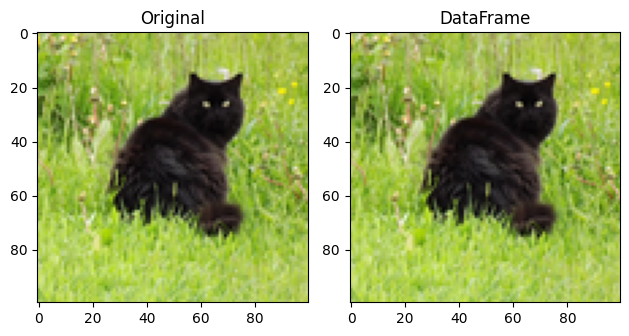

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2)

# Get the original image
img = cv2.imread("kot-kwiat/kotek-28.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Plot the original image
ax1.imshow(img_rgb)
ax1.set_title("Original")

# Reconstruct the 2D image from flattened DataFrame pixels
pixels = df1[df1["name"] == "kotek-28.png"].sort_values(["y", "x"])[RGB]
img_df = pixels.to_numpy().reshape(img.shape)

# Plot the reconstructed image
ax2.imshow(img_df)
ax2.set_title("DataFrame")

plt.tight_layout()
plt.show()

---
**Zadanie 2.**

| kategoria        | Koty                     | Kwiaty                  |
| ---------------- | ------------------------ | ----------------------- |
| dominujące barwy | czarny (i jego odcienie) | biały (i jego odcienie) |
| temperatura      | dużo zimnych kolorów     | dużo ciepłych kolorów   |

Za powyższe odpowiadają najprawdopodobniej:
- ciemne, szarawe barwy sierści,
- jasne, kolorowe barwy płatków kwiatów.

In [7]:
# Count the number of unique colors per image
df_unique = (
    df1[["name"] + RGB]
    .drop_duplicates()
    .groupby("name", sort=False)
    .size()
    .reset_index(name="unique_colors")
)

# Compute summary statistics
df_unique["unique_colors"].agg(AGG_FUNCTIONS)

min       4538.000000
max       9911.000000
mean      8649.393939
median    9072.500000
std       1163.402865
Name: unique_colors, dtype: float64

Zakres liczby unikatowych kolorów jest szeroki (od ~4500 do ~9900 kolorów).

Mediana jest wyższa od średniej, więc większość zdjęć zawiera dużo unikatowych barw, a tylko niewielka część z nich (prostych, niezróżnicowanych) zaniża średnią.

Typowe zdjęcie odstaje od średniej ~1000 kolorami. Małe minimum sugeruje obecność kilku outlierów.

In [8]:
# Extract the image names list
names = pd.Series(df1["name"].unique())

print(f"number of cat photos : {cat_indices(names).sum()}")
print(f"number of flower photos : {flower_indices(names).sum()}")

number of cat photos : 55
number of flower photos : 77


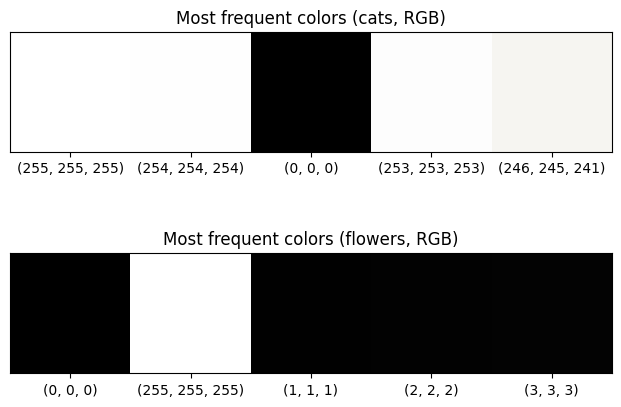

In [9]:
df2_cats = df2[cat_indices(df2["class"])]
df2_flowers = df2[flower_indices(df2["class"])]


def plot_colors(ax, df, top_n=5):
    # Get the most frequent color values
    df = df.sort_values("count", ascending=False).head(top_n)

    # Create and display the color palette
    # Note: This is essentially a 1-pixel-high image
    img = df[RGB].values.reshape(1, len(df), 3)
    ax.imshow(img)

    # Hide the non-functional Y-axis
    ax.get_yaxis().set_visible(False)

    # Add string labels for the (R, G, B) values
    labels = [
        f"({row.R}, {row.G}, {row.B})" for row in df.itertuples(index=False)
    ]
    ax.set_xticks(range(len(df)), labels)


fig, (ax1, ax2) = plt.subplots(2, 1)

# Plot the most frequent colors (cat photos)
plot_colors(ax1, df2_cats)
ax1.set_title("Most frequent colors (cats, RGB)")

# Plot the most frequent colors (flower photos)
plot_colors(ax2, df2_flowers)
ax2.set_title("Most frequent colors (flowers, RGB)")

plt.tight_layout()
plt.show()

In [10]:
# Compute summary statistics
display(df2_cats[["L", "S"]].agg(AGG_FUNCTIONS))
display(df2_flowers[["L", "S"]].agg(AGG_FUNCTIONS))

,L,S
min,0.000000,0.000000
max,255.000000,255.000000
mean,110.530698,86.607695
median,107.000000,79.000000
std,49.650290,54.878886


,L,S
min,0.000000,0.000000
max,255.000000,255.000000
mean,107.334248,127.151365
median,106.000000,116.000000
std,49.884227,72.378891


**Jasność**

Zdjęcia kotów i kwiatów nie różnią się znacząco pod względem jasności.

Mediany są bliskie średnim, więc dane rozłożone są w miarę symetrycznie.

Zdjęcia są umiarkowanie jasne - typowe `L` przyjmuje wartości z przedziału [60, 160].

**Nasycenie**

Zdjęcia kotów i kwiatów znacząco różnią się pod względem nasycenia.

Mediany są wyższe od średnich, więc kilka bardzo intensywnych zdjęć zawyża średnią.

Zdjęcia kotów są dużo mniej zróżnicowane niż zdjęcia kwiatów - niższe są zarówno średnia, mediana, jak i odchylenie standardowe:
- sierść to przede wszystkim szarości, brązy, beże (stonowane),
- płatki kwiatów to głównie czerwienie, żółcie, biele (intensywne).

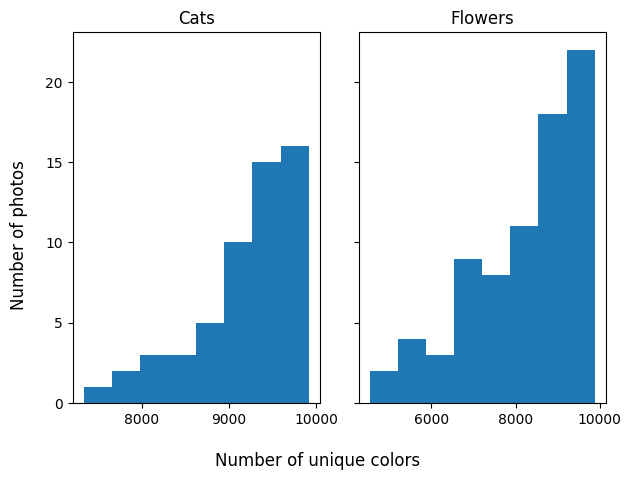

In [11]:
df_unique_cats = df_unique[cat_indices(df_unique["name"])]
df_unique_flowers = df_unique[flower_indices(df_unique["name"])]

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)

# Plot the distribution of the number of unique colors (cat photos)
ax1.hist(df_unique_cats["unique_colors"], bins="auto")
ax1.set_title("Cats")

# Plot the distribution of the number of unique colors (flower photos)
ax2.hist(df_unique_flowers["unique_colors"], bins="auto")
ax2.set_title("Flowers")

fig.supxlabel("Number of unique colors")
fig.supylabel("Number of photos")

plt.tight_layout()
plt.show()

Oba rozkłady wykazują podobny trend - ze wzostem liczby unikatowych kolorów wzrasta też liczba odpowiadających im zdjęć.

Wśród zdjęć kwiatów jest jednak:
- więcej wartości w okolicach średniej,
- większy zakres liczby unikatowych kolorów
    - dolna granica to ~4500 (w porównaniu z ~7000),
    - górna granica jest prawie identyczna.

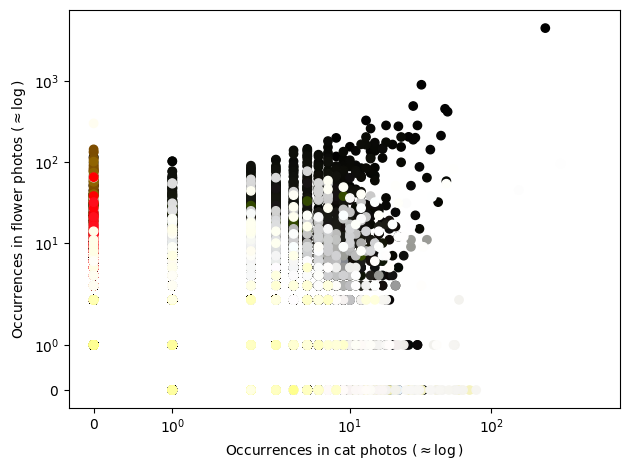

In [12]:
# Perform a FULL JOIN to align counts from both classes
df2_full = (
    df2_cats[RGB + ["count"]]
    .merge(df2_flowers[RGB + ["count"]], on=RGB, how="outer")
    .fillna(0)
)

# Plot each color's frequency in both classes
colors = df2_full[RGB].values / 255
plt.scatter(df2_full["count_x"], df2_full["count_y"], c=colors)

# Rescale both axes to ensure outliers are visible
plt.xscale("symlog")
plt.yscale("symlog")

plt.xlabel("Occurrences in cat photos ($\\approx \\log$)")
plt.ylabel("Occurrences in flower photos ($\\approx \\log$)")

plt.tight_layout()
plt.show()

Odcienie szarości występują w miarę równomiernie w zdjęciach kotów i kwiatów.

Część pozostałych kolorów (m.in. żółcie, zielenie) występuje w podobnej liczbie - niezależnie od tego, jak często pojawia się na zdjęciach w drugiej klasie. Sugeruje to obecność stałego dla danej klasy tła (np. trawy).

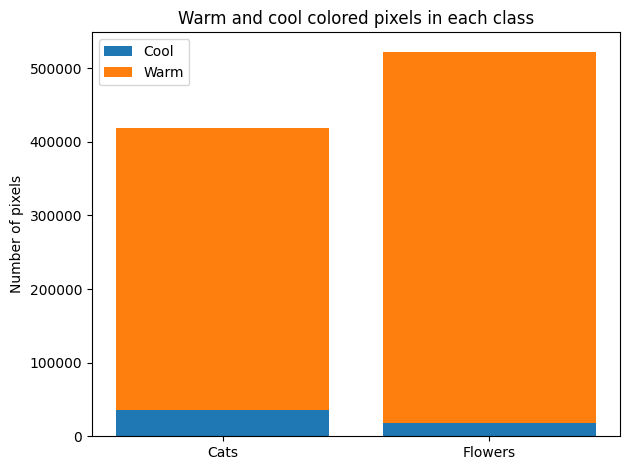

In [13]:
# Count cool-colored pixels
cool_count = [
    df2_cats["czy_zimny"].sum(),
    df2_flowers["czy_zimny"].sum(),
]

# Count warm-colored pixels (as the remainder of total pixel count)
warm_count = [
    len(df) - cool_count[i] for i, df in enumerate([df2_cats, df2_flowers])
]

# Plot a stacked bar chart
bottom = np.zeros(2)
for pixel_count, label in zip([cool_count, warm_count], ["Cool", "Warm"]):
    plt.bar(["Cats", "Flowers"], pixel_count, label=label, bottom=bottom)
    bottom += pixel_count

plt.ylabel("Number of pixels")
plt.title("Warm and cool colored pixels in each class")
plt.legend()

plt.tight_layout()
plt.show()

W obu klasach zdecydowanie przeważają barwy ciepłe, przy czym barw zimnych jest (proporcjonalnie) 2-3 krotnie więcej na zdjęciach kotów.

---
**Zadanie 3.**

W klasteryzacji zastosuję składowe RGB z pierwszego zbioru danych, ponieważ:
- przestrzenna reprezentacja składowych pasuje do metod opartych na odległości euklidesowej (K-Means, K-Medoids),
- piksele z powtórzeniami lepiej odzwierciedlają dominujące barwy (środki klastrów przesuwają się bliżej nich).

Sama skala RGB nie jest jednak liniowa (w fizycznym sensie, proporcjonalnie do ilości światła), więc zamienię ją na Linear RGB.

<small>https://stackoverflow.com/questions/12524623/what-are-the-practical-differences-when-working-with-colors-in-a-linear-vs-a-no</small>

Wszystkie składowe Linear RGB mają ten sam zakres wartości (tj. [0-255]), więc nie ma potrzeby skalowania jakiejkolwiek z nich. Centrowanie też nie jest konieczne, bo nie zmienia odległości.

In [14]:
df_lrgb = df1[["name", "y", "x"] + RGB].copy()

# Reshape NumPy array into OpenCV's image-like shape
img_rgb = df_lrgb[RGB].to_numpy().reshape(-1, 1, 3)

# Convert from sRGB to Linear RGB
img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
img_lrgb = cv2.cvtColor(img_lab, cv2.COLOR_LAB2LRGB)

# Reshape back (drop the "dummy" dimension)
df_lrgb[RGB] = img_lrgb.reshape(-1, 3)

df_lrgb

,name,y,x,R,G,B
0,kotek-0.png,0,0,59,76,15
1,kotek-0.png,0,1,101,130,23
2,kotek-0.png,0,2,172,181,88
3,kotek-0.png,0,3,63,57,23
4,kotek-0.png,0,4,5,7,1
...,...,...,...,...,...,...
1319995,kwiatek-9.png,99,95,1,2,1
1319996,kwiatek-9.png,99,96,2,2,1
1319997,kwiatek-9.png,99,97,3,3,2
1319998,kwiatek-9.png,99,98,5,4,3


In [15]:
def process_image(name, df):
    pixels = df[RGB].to_numpy()

    results = []
    for algorithm in ["kmeans", "kmedoids"]:
        # K-Medoids with FasterPAM takes a precomputed distance matrix
        if algorithm == "kmedoids":
            distmatrix = pairwise_distances(pixels)

        for n_clusters in CLUSTERS:
            # Run clustering multiple times to reduce randomness' impact
            predictions = []
            for seed in SEEDS:
                if algorithm == "kmeans":
                    model = KMeans(n_clusters, random_state=seed, n_init=1)
                    labels = model.fit_predict(pixels)
                else:
                    model = KMedoids(
                        n_clusters, method="fasterpam", random_state=seed
                    )
                    labels = model.fit_predict(distmatrix)
                predictions.append(labels)

            # Calculate average Silhouette score
            silhouette_score_mean = np.mean(
                [
                    silhouette_score(pixels, prediction)
                    for prediction in predictions
                ]
            )

            # Calculate average Calinski-Harabasz index
            chi_mean = np.mean(
                [
                    calinski_harabasz_score(pixels, prediction)
                    for prediction in predictions
                ]
            )

            results.append(
                {
                    "name": name,
                    "algorithm": algorithm,
                    "k": n_clusters,
                    "silhouette_score": silhouette_score_mean,
                    "chi": chi_mean,
                }
            )

    return results


if CLUSTERING_PRECOMPUTED_SRC is not None:
    # Load the precomputed results
    df_clusters = pd.read_csv(CLUSTERING_PRECOMPUTED_SRC)
else:
    # Run the parallel clustering pipeline accross all images
    # Note: n_jobs=-1 uses all available CPU cores
    results_list = Parallel(n_jobs=-1, verbose=10)(
        [
            delayed(process_image)(name, df)
            for name, df in df_lrgb.groupby("name")
        ]
    )

    # Merge all results into a single DataFrame
    df_clusters = pd.DataFrame(
        [row for results in results_list for row in results]
    )

df_clusters

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[Parallel(n_jobs=-1)]: Done   9 out of 132 | elapsed: 22.0min
[Parallel(n_jobs=-1)]: Done  18 out of 132 | elapsed: 43.3min
[Parallel(n_jobs=-1)]: Done  29 out of 132 | elapsed: 45.2min
[Parallel(n_jobs=-1)]: Done  40 out of 132 | elapsed: 66.2min
[Parallel(n_jobs=-1)]: Done  53 out of 132 | elapsed: 86.9min
[Parallel(n_jobs=-1)]: Done  66 out of 132 | elapsed: 105.6min
[Parallel(n_jobs=-1)]: Done  81 out of 132 | elapsed: 123.4min
[Parallel(n_jobs=-1)]: Done  96 out of 132 | elapsed: 145.4min
[Parallel(n_jobs=-1)]: Done 115 out of 132 | elapsed: 168.0min remaining: 24.8min
[Parallel(n_jobs=-1)]: Done 129 out of 132 | elapsed: 180.7min remaining:  4.2min
[Parallel(n_jobs=-1)]: Done 132 out of 132 | elapsed: 181.1min finished


,name,algorithm,k,silhouette_score,chi
0,kotek-0.png,kmeans,5,0.520613,17523.736984
1,kotek-0.png,kmeans,6,0.507234,16654.507708
2,kotek-0.png,kmeans,7,0.492386,16300.666830
3,kotek-0.png,kmeans,8,0.470687,16040.752878
4,kotek-0.png,kmeans,9,0.471469,15940.624382
...,...,...,...,...,...
4219,kwiatek-9.png,kmedoids,16,0.385602,18767.050197
4220,kwiatek-9.png,kmedoids,17,0.373547,18406.025747
4221,kwiatek-9.png,kmedoids,18,0.358131,18125.216261
4222,kwiatek-9.png,kmedoids,19,0.357824,18234.973374


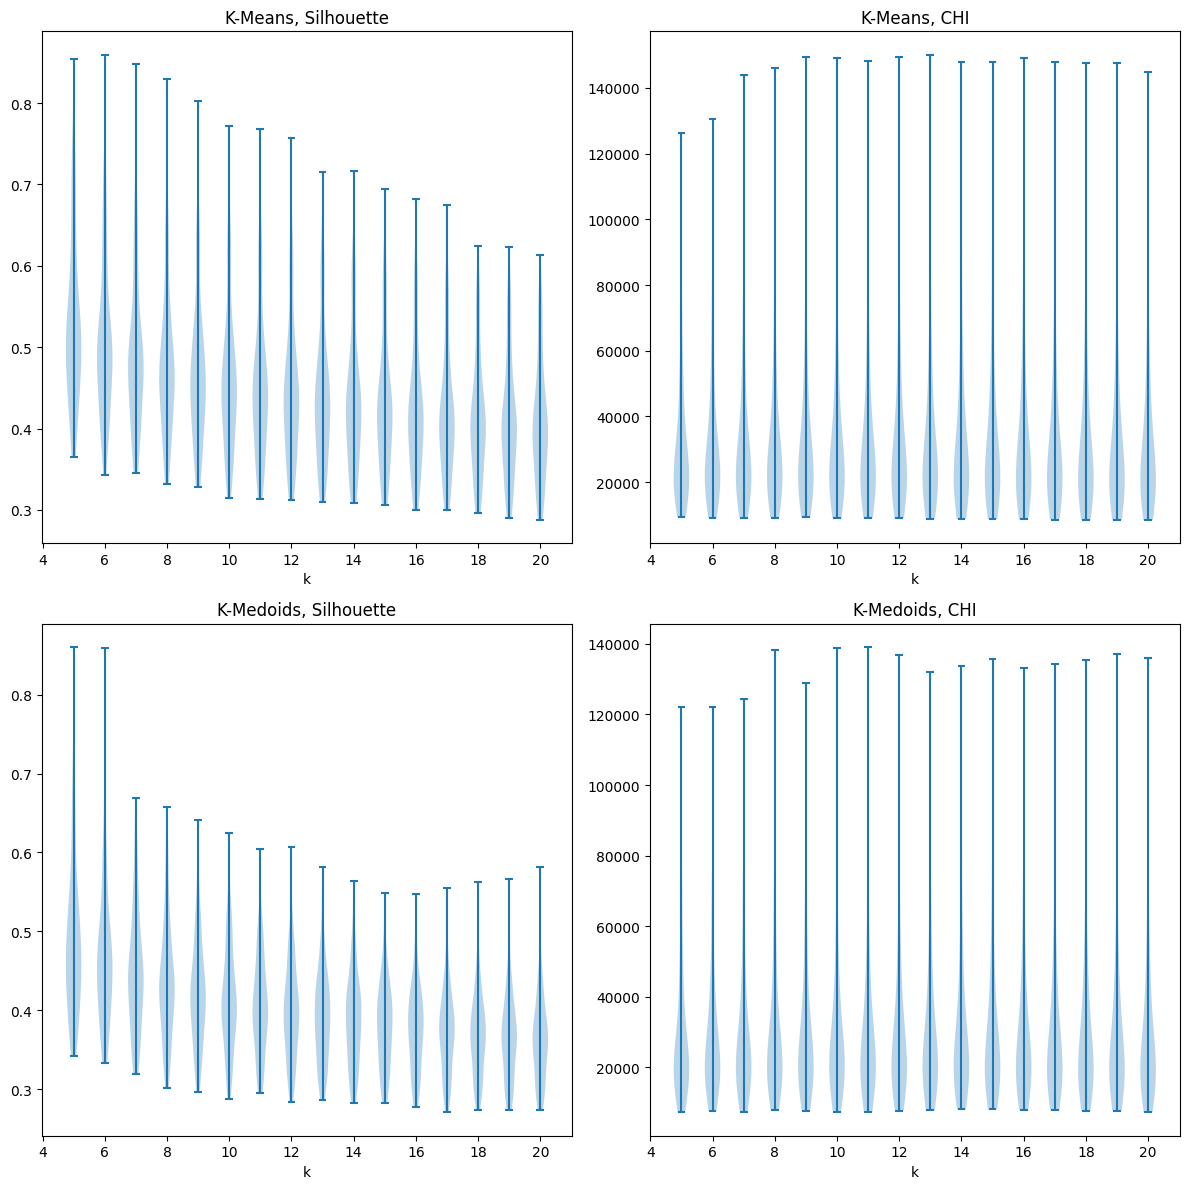

In [16]:
df_clusters_kmeans = df_clusters[df_clusters["algorithm"] == "kmeans"]
df_clusters_kmedoids = df_clusters[df_clusters["algorithm"] == "kmedoids"]

# Group scores by type (Silhouette, CHI) and algorithm (K-Means, K-Medoids)
scores = {
    name: [
        df.groupby("k")[name].apply(list)
        for df in [df_clusters_kmeans, df_clusters_kmedoids]
    ]
    for name in ["silhouette_score", "chi"]
}

fig, ax = plt.subplots(2, 2, figsize=(12, 12))

# Plot the K-Means performance across different cluster counts (silhouette)
ax[0, 0].violinplot(scores["silhouette_score"][0], positions=CLUSTERS)
ax[0, 0].set_title("K-Means, Silhouette")

# Plot the K-Means performance across different cluster counts (CHI)
ax[0, 1].violinplot(scores["chi"][0], positions=CLUSTERS)
ax[0, 1].set_title("K-Means, CHI")

# Plot the K-Medoids performance across different cluster counts (silhouette)
ax[1, 0].violinplot(scores["silhouette_score"][1], positions=CLUSTERS)
ax[1, 0].set_title("K-Medoids, Silhouette")

# Plot the K-Medoids performance across different cluster counts (CHI)
ax[1, 1].violinplot(scores["chi"][1], positions=CLUSTERS)
ax[1, 1].set_title("K-Medoids, CHI")

# Add labels (cluster count)
for x, y in np.ndindex(2, 2):
    ax[x, y].set_xlabel("k")

plt.tight_layout()
plt.show()

*K-Means*

Właściwa wartość hiperparametru `k` to 9, ponieważ:
- silhouette zdecydowanie faworyzuje mniejsze wartości (gęstości przesuwają się coraz niżej),
- CHI nie różni się znacząco gęstościami, ale od `k` = 9 zaczyna osiągać swoje największe maksima (dla silhouette to wciąż wystarczająco mało, by dawać przyzwoity wynik).

*K-Medoids*

Właściwa wartość hiperparametru `k` to 8, ponieważ:
- podobnie, silhouette faworyzuje mniejsze wartości,
- podobnie, CHI ma duże maksimum w `k` = 8.

Co prawda, od `k` = 7 drastycznie spada maksimum w silhouette, ale interpretuję to jako niestabilność K-Medoids dla małych `k` (ponieważ dalej nie ma już takich spadków). CHI uważam w tym przypadku za bardziej miarodajne.


In [17]:
# Initialize clustering models with chosen k values
kmeans = KMeans(9, random_state=SEEDS[0], n_init=1)
kmedoids = KMedoids(8, metric="euclidean", random_state=SEEDS[0])

df_rgb_kmeans, df_rgb_kmedoids = df_lrgb.copy(), df_lrgb.copy()

# Replace original colors with their assigned clusters (K-Means)
predictions = kmeans.fit_predict(df_rgb_kmeans[RGB].to_numpy())
df_rgb_kmeans[RGB] = kmeans.cluster_centers_.astype(np.uint8)[predictions]

# Fit K-Medoids on a random sample to avoid MemoryError
# Note: These predictions are close enough, but not entirely accurate
predictions = kmedoids.fit(
    df_rgb_kmedoids[RGB]
    .sample(
        min(KMEDOIDS_SAMPLE_SIZE, len(df_rgb_kmedoids)), random_state=SEEDS[0]
    )
    .to_numpy()
).predict(df_rgb_kmedoids[RGB].to_numpy())

# Replace original colors with their assigned clusters (K-Medoids)
mapping = {medoid: i for i, medoid in enumerate(kmedoids.medoid_indices_)}
predictions = [mapping[prediction] for prediction in predictions]
df_rgb_kmedoids[RGB] = kmedoids.cluster_centers_[predictions]

for df in [df_rgb_kmeans, df_rgb_kmedoids]:
    # Reshape NumPy array into OpenCV's image-like shape
    img_lrgb = df[RGB].to_numpy().reshape(-1, 1, 3)

    # Convert from Linear RGB to sRGB
    img_lab = cv2.cvtColor(img_lrgb, cv2.COLOR_LRGB2LAB)
    img_rgb = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)

    # Reshape back (drop the "dummy" dimension)
    df[RGB] = img_rgb.reshape(-1, 3)

display(df_rgb_kmeans)
display(df_rgb_kmedoids)

,name,y,x,R,G,B
0,kotek-0.png,0,0,114,125,81
1,kotek-0.png,0,1,151,182,94
2,kotek-0.png,0,2,218,203,110
3,kotek-0.png,0,3,114,125,81
4,kotek-0.png,0,4,58,58,33
...,...,...,...,...,...,...
1319995,kwiatek-9.png,99,95,58,58,33
1319996,kwiatek-9.png,99,96,58,58,33
1319997,kwiatek-9.png,99,97,58,58,33
1319998,kwiatek-9.png,99,98,58,58,33


,name,y,x,R,G,B
0,kotek-0.png,0,0,107,143,73
1,kotek-0.png,0,1,162,176,114
2,kotek-0.png,0,2,203,196,170
3,kotek-0.png,0,3,142,116,94
4,kotek-0.png,0,4,33,39,23
...,...,...,...,...,...,...
1319995,kwiatek-9.png,99,95,33,39,23
1319996,kwiatek-9.png,99,96,33,39,23
1319997,kwiatek-9.png,99,97,33,39,23
1319998,kwiatek-9.png,99,98,33,39,23


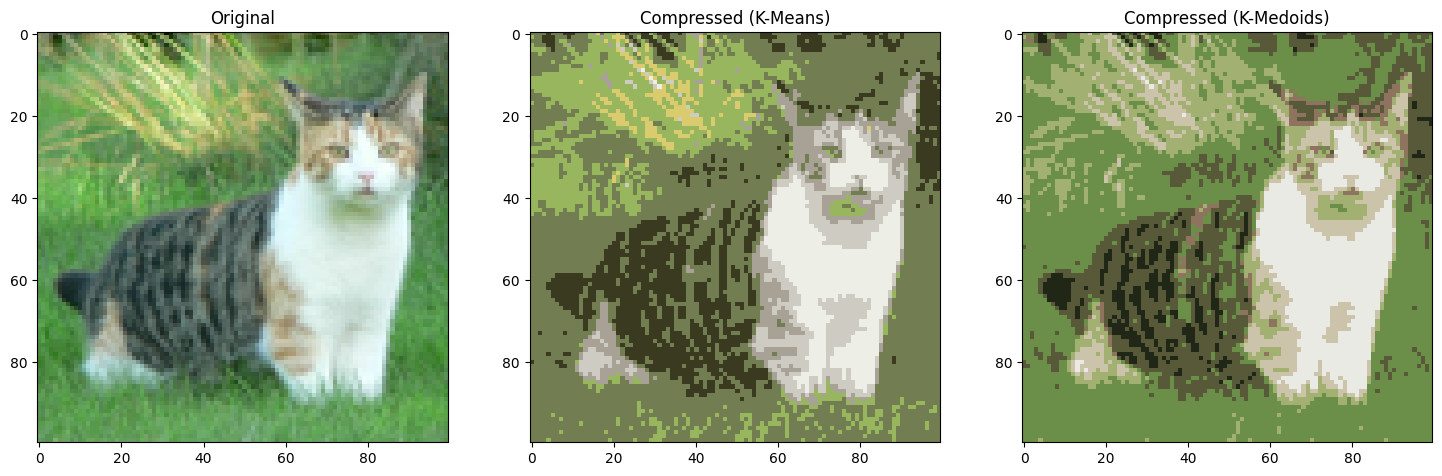

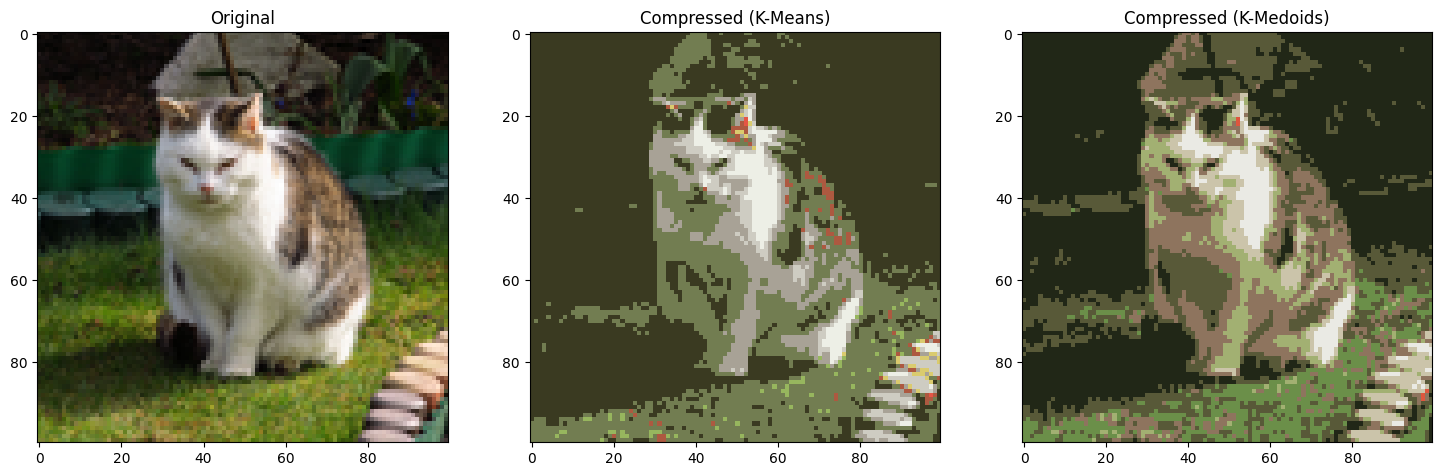

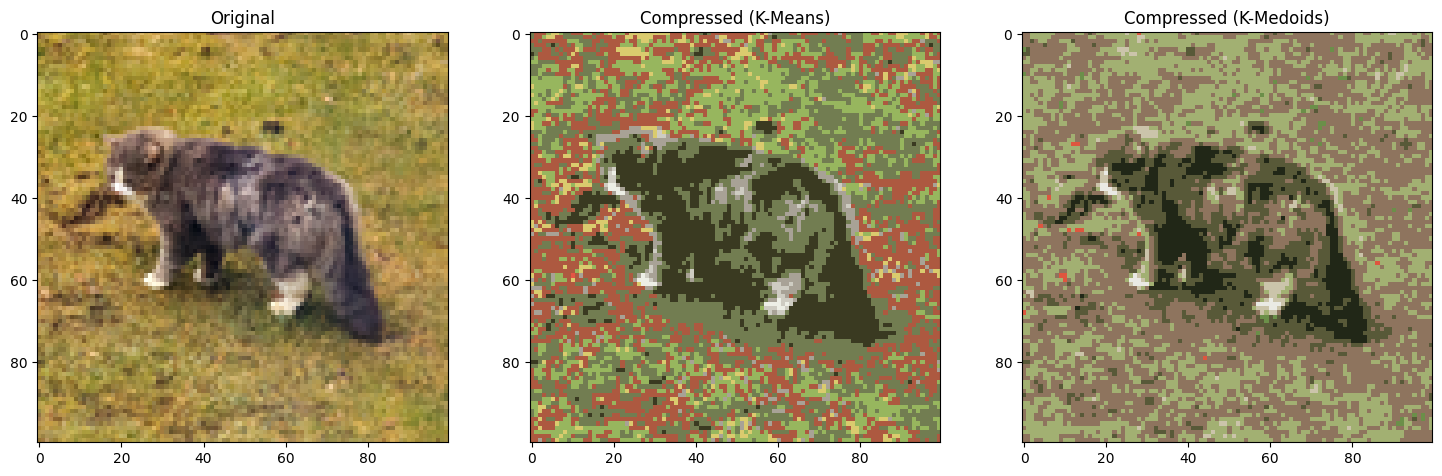

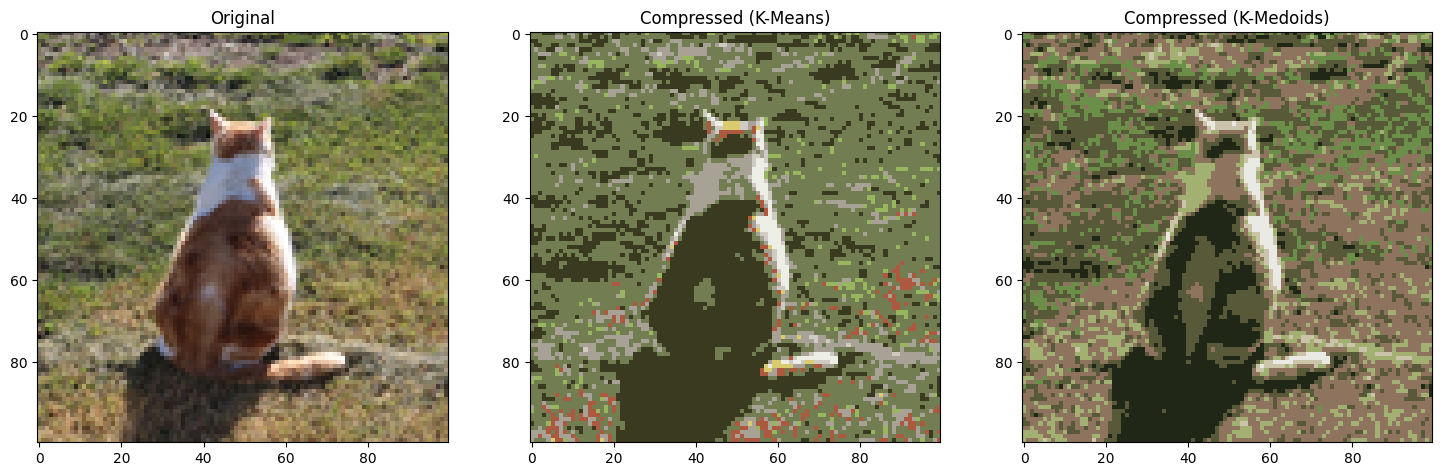

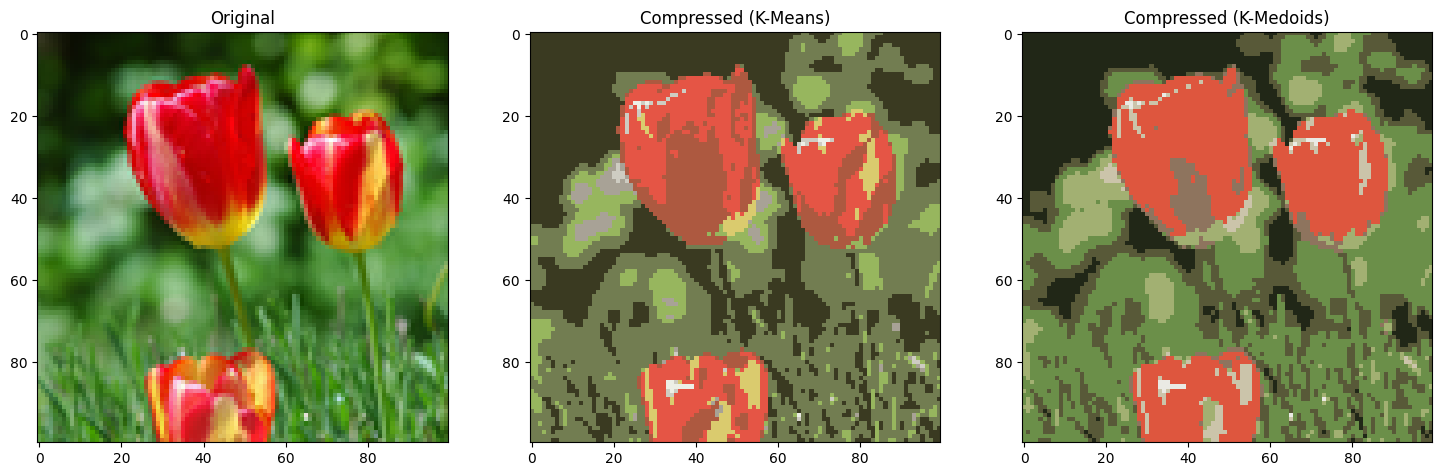

In [18]:
for name in names.sample(5, random_state=SEEDS[0]):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    for i, df in enumerate([df1, df_rgb_kmeans, df_rgb_kmedoids]):
        # Reconstruct the 2D image from flattened DataFrame pixels
        pixels = df[df["name"] == name].sort_values(["y", "x"])[RGB]
        img_df = pixels.to_numpy().reshape(img.shape)  # (100, 100, 3)

        # Plot the reconstructed image
        ax[i].imshow(img_df)

    # Add titles (image source)
    for i, title in enumerate(
        ["Original", "Compressed (K-Means)", "Compressed (K-Medoids)"]
    ):
        ax[i].set_title(title)

Wybieram algorytm K-Medoids, ponieważ - względem K-Means, mimo mniejszego `k` i dopasowania jedynie na podzbiorze danych - skompresowane zdjęcia zauważalnie mniej zlewają się z tłem i lepiej odwzorowują szczegóły (np. cienie).

---
**Zadanie 4.**

In [19]:
compression_gains = []


def compression_gain(original_size, compressed_size):
    return (original_size - compressed_size) / original_size * 100


for name, df in df_rgb_kmedoids.groupby("name"):
    # Reconstruct the 2D image from flattened DataFrame pixels
    pixels = df.sort_values(["y", "x"])[RGB]
    img_df = pixels.to_numpy().reshape(img.shape)  # (100, 100, 3)

    # Save the compressed image
    comp_path = IMAGE_COMP_PATH / name
    comp_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(comp_path), img_df)

    # Calculate and save the compression gain
    original_size = (IMAGE_PATH / name).stat().st_size
    compression_gains.append(
        {
            "name": name,
            "compression_gain": compression_gain(
                original_size, comp_path.stat().st_size
            ),
        }
    )

# Merge all results into a single DataFrame
df_compression_gain = pd.DataFrame(compression_gains)

df_compression_gain

,name,compression_gain
0,kotek-0.png,54.731264
1,kotek-1.png,65.658042
2,kotek-10.png,61.753314
3,kotek-11.png,66.204677
4,kotek-12.png,65.174715
...,...,...
127,kwiatek-74.png,77.415924
128,kwiatek-75.png,60.685012
129,kwiatek-76.png,62.528539
130,kwiatek-8.png,74.568966


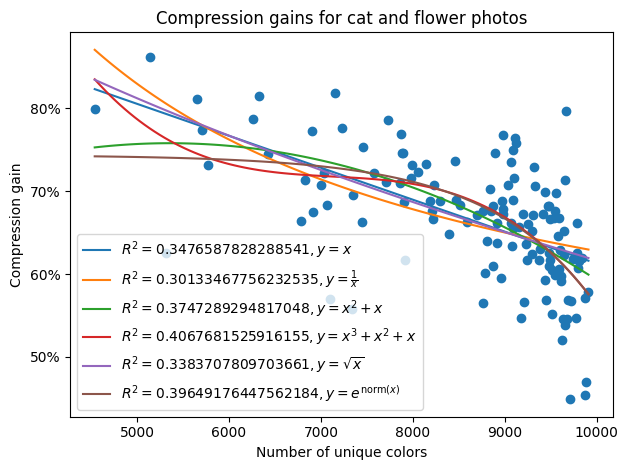

In [20]:
# Perform an INNER JOIN to combine data for linear regression
df_data = df_unique.merge(df_compression_gain, on="name", how="inner")

# Extract features (X) and targets (y)
X = df_data["unique_colors"].to_numpy().reshape(-1, 1)
y = df_data["compression_gain"]

# Plot the regression data
# Note: Set percentage units for the Y-axis
plt.scatter(X, y)
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))


def fit_and_plot(X, y, transform, label):
    # Fit and evaluate a linear regression model
    model = LinearRegression().fit(transform(X), y)
    score = r2_score(y, model.predict(transform(X)))

    # Plot the regression line
    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.coef_ @ transform(x_line).T + model.intercept_
    plt.plot(x_line, y_line, label=rf"$R^2 = {score}, y = {label}$")


# Test various functional forms to find the most accurate relationship
for transform, label in [
    (lambda x: x, "x"),
    (lambda x: 1 / x, "\\frac{1}{x}"),
    (lambda x: np.column_stack([x**2, x]), "x^2 + x"),
    (lambda x: np.column_stack([x**3, x**2, x]), "x^3 + x^2 + x"),
    (lambda x: np.sqrt(x), "\\sqrt{x}"),
    (lambda x: np.exp((x - np.mean(X)) / np.std(X)), "e^{\\text{norm}(x)}"),
]:
    fit_and_plot(X, y, transform, label)

plt.xlabel("Number of unique colors")
plt.ylabel("Compression gain")
plt.title("Compression gains for cat and flower photos")
plt.legend()

plt.tight_layout()
plt.show()

---
**Zadanie 5.**

In [21]:
y_list, X_orig_list, X_komp_list = [], [], []

for name, is_cat in zip(names, cat_indices(names)):
    y_list.append(is_cat)

    # Read both the original and compressed versions of the image
    img_orig = cv2.imread(IMAGE_PATH / name)
    img_comp = cv2.imread(IMAGE_COMP_PATH / name)

    # Map (R, G, B) channels into a single unique identifier (base-1000)
    for src, dst in zip([img_orig, img_comp], [X_orig_list, X_komp_list]):
        b, g, r = [channel.ravel() for channel in cv2.split(src)]
        dst.append(np.stack([1000**2, 1000, 1]) @ [r, g, b])

# Merge all values into a single NumPy array
y, X_orig, X_komp = (
    np.stack(y_list),
    np.stack(X_orig_list),
    np.stack(X_komp_list),
)

print(f"{y.shape=}")
print(f"{X_orig.shape=}")
print(f"{X_komp.shape=}")

y.shape=(132,)
X_orig.shape=(132, 10000)
X_komp.shape=(132, 10000)


In [22]:
# Split the dataset into training (90%) and test (10%) sets
X_orig_train, X_orig_test, X_komp_train, X_komp_test, y_train, y_test = (
    train_test_split(X_orig, X_komp, y, test_size=0.1, random_state=SEEDS[0])
)

In [23]:
def get_best_estimator(X, y):
    # Find the optimal model using grid search with cross-validation
    gs = GridSearchCV(
        KNeighborsClassifier(),
        param_grid={
            "n_neighbors": range(1, 4 * len(X) // 5)
        },  # up to the maximum value for 5-fold CV
        cv=5,
        scoring="f1",
    )
    return gs.fit(X, y).best_estimator_


# Get the optimal classifiers for original and compressed photos
model_orig = get_best_estimator(X_orig_train, y_train)
model_komp = get_best_estimator(X_komp_train, y_train)

print(f"n_neighbors for X_orig : {model_orig.get_params()["n_neighbors"]}")
print(f"n_neighbors for X_komp : {model_komp.get_params()["n_neighbors"]}")

n_neighbors for X_orig : 22
n_neighbors for X_komp : 1


In [24]:
# Evaluate and compare both models' performance
for name, model, (X_train, X_test) in zip(
    ["Original", "Compressed"],
    [model_orig, model_komp],
    [(X_orig_train, X_orig_test), (X_komp_train, X_komp_test)],
):
    print(name)

    # Calculate training, validation and test scores
    scores = {
        "training": f1_score(y_train, model.predict(X_train)),
        "validation": cross_val_score(
            model, X_train, y_train, cv=5, scoring="f1"
        ).mean(),
        "test": f1_score(y_test, model.predict(X_test)),
    }

    print(f"* training score : {scores["training"]}")
    print(f"* validation score (5-fold, mean) : {scores["validation"]}")
    print(f"* test score : {scores["test"]}")

Original
* training score : 0.7047619047619048
* validation score (5-fold, mean) : 0.6857499479925109
* test score : 0.7368421052631579
Compressed
* training score : 1.0
* validation score (5-fold, mean) : 0.4382600732600733
* test score : 0.6666666666666666


Zastosowanie kompresji znacząco pogorszyło jakość dopasowania, ponieważ model ma wtedy skłonność do skrajnego przeuczenia, o czym świadczą:
- bardzo wysoki wynik na zbiorze treningowym,
- względnie niski wynik na zbiorze walidacyjnym.

Przesłanką ku temu jest również fakt, iż wynik na zbiorze walidacyjnym byłby wyższy, gdyby tylko model w każdym przypadku zwracał przeciwny wynik.

Wartość miary F1 na zbiorze testowym również spadła, choć jedynie o 5-6% - przy tak niestabilnym modelu i niewielkim zbiorze testowym jest to wyłącznie efektem czystego przypadku.